In [4]:
# 고객 이탈(Churn) 예측을 위한 탐색적 데이터 분석 (EDA)
# 본 노트북은 `synthetic_customer_churn_100k.csv` 데이터를 분석하여 이탈 모델링(LightGBM 등)에 필요한 인사이트를 도출하기 위해 작성되었습니다."
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 한글 폰트 설정 (VS Code 실행 환경에 따라 조정 가능)
plt.rc('font', family='Malgun Gothic') # Windows
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

In [5]:
# 데이터 불러오기 (파일 경로 확인 필요)
df = pd.read_csv('synthetic_customer_churn_100k.csv')
print(f"데이터 크기: {df.shape}")
df.head()

데이터 크기: (100000, 9)


,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [6]:
# 요약 정보 및 결측치 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  str    
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  str    
 6   PaymentMethod   100000 non-null  str    
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 6.9 MB


In [7]:
# 수치형 변수 기초 통계량
df.describe()

# 요약: df.describe() 출력 후 1분 만에 스캔하는 법
# Count: 모든 변수의 count 수가 100,000으로 동일한가? (다르다면 결측치 존재 확인)

# Min: 0보다 작은 마이너스 등 말도 안 되는 숫자가 있는가?

# Max: 혼자서만 붕 떠 있는 터무니없이 큰 숫자가 있는가?

# TotalCharges: 평균이 중위값보다 훨씬 큰가? (오른쪽 꼬리가 긴 분포임을 인지)

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


- 머신러닝(LightGBM) 모델의 성능을 높이고 데이터의 오류를 잡아내기 위해 반드시 확인해야할 4가지
1. 이상치(Outlier)와 데이터 오류 잡아내기 (Min / Max 확인)
    - 나이 (Age): 최솟값이 음수이거나, 최댓값이 150세처럼 비현실적인 숫자가 있다면 데이터 수집 오류입니다.
    - 가입 기간 (Tenure): 가입 개월 수를 뜻하므로 0 미만의 마이너스 값이 있는지 확인해야 합니다.
    - 이용 요금 (MonthlyCharges, TotalCharges): 요금이 0원 이하(음수)로 찍혀 있다면 무료 프로모션 대상자인지, 혹은 시스템 오류인지 판별해야 합니다.
    - 만약 최댓값이 평균이나 75% 지점(3사분위수)에 비해 지나치게 크다면, 극단적인 이상치(Outlier)가 존재한다는 뜻입니다. 트리 기반 모델인 LightGBM은 이상치에 비교적 강하지만, 데이터 자체의 오류일 수 있으므로 먼저 걸러내는 것이 좋습니다.

2. 데이터 분포의 치우침 (Mean vs 50% 중위값 비교)
- 평균(mean)과 50% 지점인 중위값(median)을 비교하면 데이터가 한쪽으로 쏠려 있는지(Skewed) 알 수 있습니다. 특히 이 데이터에서는 TotalCharges (총 청구 금액)를 주의 깊게 봐야 합니다.
- mean $\approx$ 50% (중위값): 데이터가 대칭적인 정규분포에 가깝게 예쁘게 모여 있다는 뜻입니다.
- mean $>$ 50% (중위값): 데이터가 왼쪽으로 치우쳐 있고, 오른쪽으로 긴 꼬리를 가진 분포(Right-skewed)입니다.
    - 보통 TotalCharges 같은 금액 데이터가 이렇습니다. 대다수 고객은 적은 금액을 내지만, 몇몇 헤비 유저(장기 가입자)가 엄청나게 큰 금액을 내면서 평균을 위로 끌어올리기 때문입니다.

- LightGBM 연계 인사이트: LightGBM은 값의 절대적인 크기보다 순서(Rank)를 중요하게 보기 때문에 왜도(치우침)에 덜 민감합니다. 하지만 데이터 분포가 너무 한쪽으로 쏠려 있다면, 모델이 상위 고액 예측을 잘 하도록 로그 변환(np.log1p) 등을 고려해 볼 수 있습니다.

3. 변수 간의 논리적 모순 확인 (Tenure와 Charges의 관계)
- 수치형 변수들이 서로 아귀가 맞는지 기초 통계량의 '스케일'을 통해 추론해 볼 수 있습니다.
- 논리적 공식: TotalCharges(총 금액) $\approx$ Tenure(가입 기간) $\times$ MonthlyCharges(월 금액) 가 성립해야 합니다.
- 만약 Tenure 가 최대 72개월이고 MonthlyCharges가 최대 150인데, TotalCharges의 최댓값이 수억 원대로 찍혀 있다면 데이터 매칭이 잘못된 것입니다.
- 반대로 가입 기간(Tenure)의 최솟값이 0인데 TotalCharges가 수십만 원씩 찍혀 있다면, 중도 해지 후 재가입한 고객인지 등 데이터의 정의를 다시 확인해야 합니다.

4. 데이터의 범위(Scale) 확인과 트리 모델의 특징
- df.describe()를 보면 변수마다 숫자의 단위(Scale)가 완전히 다를 것입니다.
- Age나 Tenure는 수십 단위 (0~100)
- MonthlyCharges는 수백 단위 (10~200)
- TotalCharges는 수만 단위 (0~10,000)

- LightGBM을 쓸 때의 대반전:
선형 회귀(Linear Regression)나 딥러닝에서는 이렇게 단위가 다르면 반드시 스케일링(StandardScaler 등)을 해야 모델이 망가지지 않습니다. 하지만 LightGBM 같은 트리 기반 모델은 변수의 절대적인 크기가 아니라 '값의 대소 관계'로 데이터를 분할하기 때문에 스케일링을 전혀 안 해도 성능에 아무런 지장이 없습니다. 즉, 스케일이 다른 것을 확인하되 "아, LightGBM을 쓸 거니까 굳이 Standard Scaler 같은 전처리는 생략해도 되겠구나"라고 판단하시면 됩니다.

In [8]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

--- Churn 빈도수 ---
Churn
No     66856
Yes    33144
Name: count, dtype: int64
---Churn 비율(%) ---
Churn
No     66.856
Yes    33.144
Name: proportion, dtype: float64


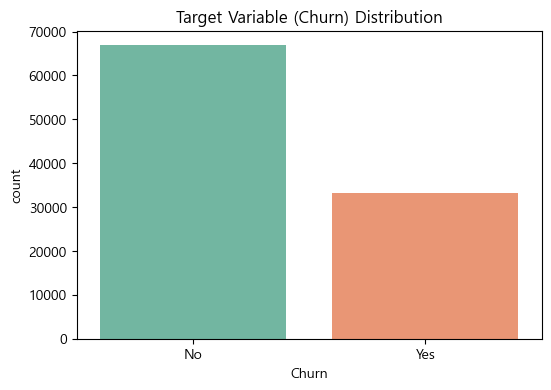

In [9]:
# 2. 타겟 변수(Churn) 분포 확인
#"이탈율이 얼마나 되는지 파악하고, 클래스 불균형(Imbalance) 여부를 확인합니다."
churn_counts = df['Churn'].value_counts()
churn_rates = df['Churn'].value_counts(normalize=True) * 100
print("--- Churn 빈도수 ---")
print(churn_counts)
print("---Churn 비율(%) ---")
print(churn_rates)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Target Variable (Churn) Distribution')
plt.show()

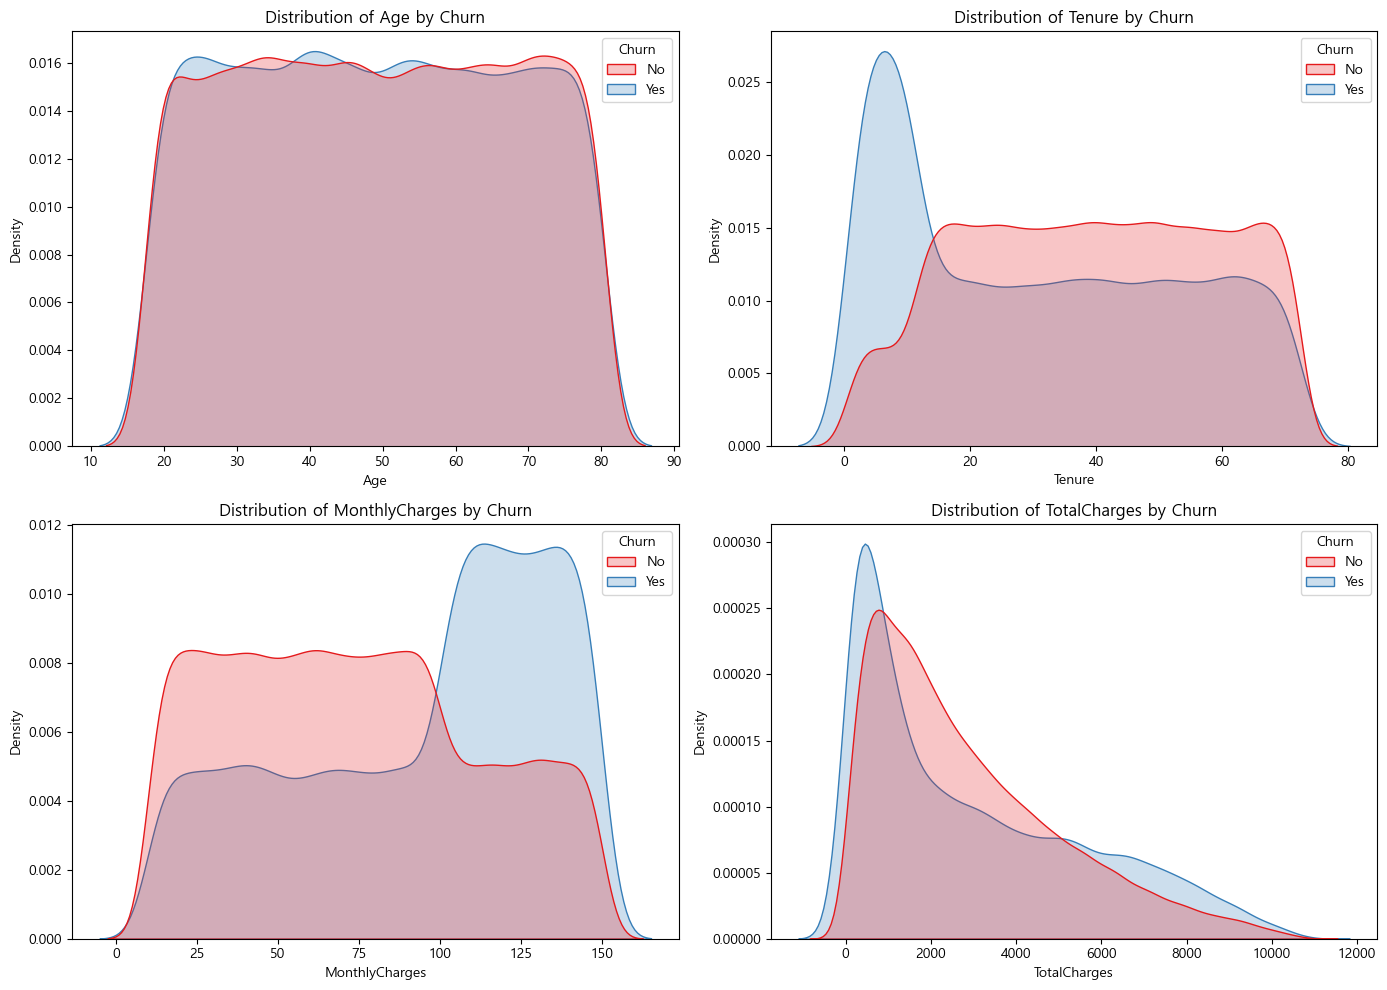

NameError: name 'os' is not defined

In [10]:
# 3. 수치형 변수 분석 (Age, Tenure, MonthlyCharges, TotalCharges)
# 수치형 변수들이 이탈 여부에 따라 어떤 분포 차이를 보이는지 시각화합니다.
num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, ax=axes[i], palette='Set1')
    axes[i].set_title(f'Distribution of {col} by Churn')

plt.tight_layout()
plt.show()

# 파일로 저장 후 닫기
plot1_path = os.path.join(output_dir, '05_churn_distribution.png')
plt.savefig(plot1_path, dpi=150)
plt.close()
print(f"-> 저장 완료: {plot1_path}")

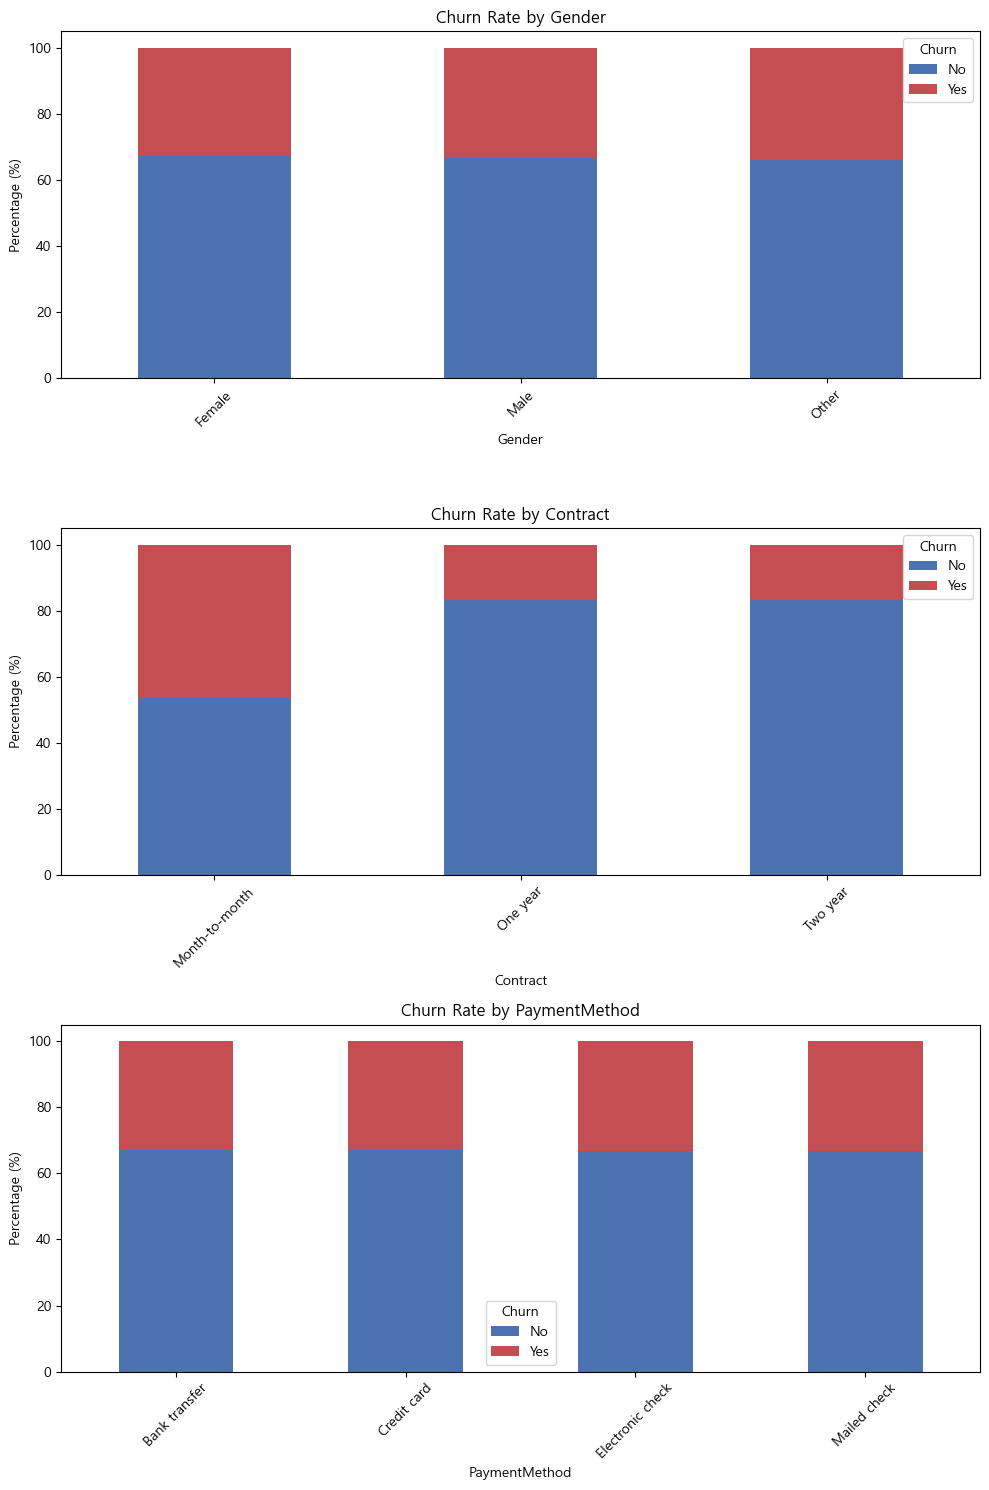

In [ ]:
# 4. 범주형 변수 분석 (Gender, Contract, PaymentMethod)
# 계약 유형이나 결제 수단에 따라 이탈률에 유의미한 차이가 있는지 분석합니다.
cat_cols = ['Gender', 'Contract', 'PaymentMethod']
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
for i, col in enumerate(cat_cols):
    # 백분율 기준의 Stacked Bar Chart 작성을 위해 크로스탭 생성
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#4c72b0', '#c44e52'])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

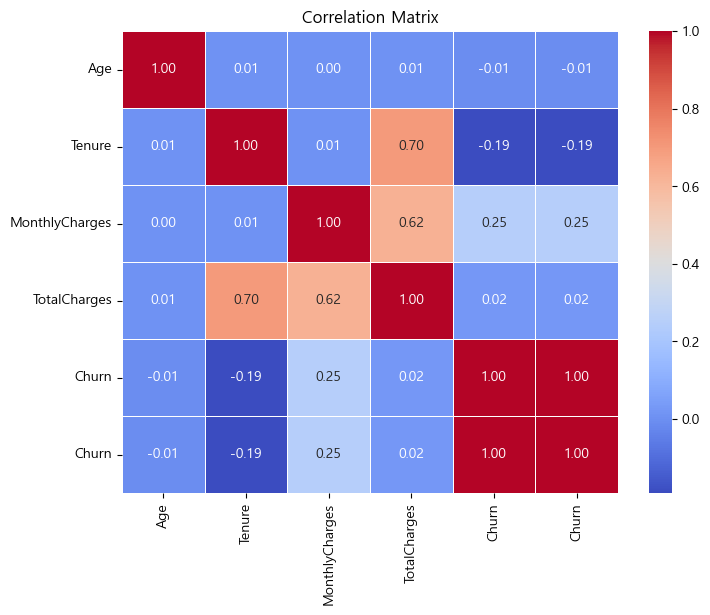

               변수        VIF
0    TotalCharges  11.164562
1          Tenure   8.949542
2  MonthlyCharges   8.319921
3             Age   6.087550


In [ ]:
# 5. 변수 간 상관관계 분석 (Correlation Matrix)
# 수치형 특성들 간의 다중공선성(Multicollinearity)이나 타겟과의 연관성을 파악합니다.
# 상관관계 분석을 위해 Churn 변수를 0과 1로 매핑
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr[num_cols + ['Churn']].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

df_corr

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']  # 수치형 변수 리스트 (Churn 포함)

# VIF 계산 (수치형 변수만)
vif_data = pd.DataFrame()
vif_data['변수'] = num_cols
vif_data['VIF'] = [variance_inflation_factor(df_corr[num_cols].values, i) 
                   for i in range(len(num_cols))]

vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_data)



6. EDA 결론 및 모델링을 위한 제언
- **결측치:** 결측치 존재 여부에 따라 처리 필요 (LightGBM은 자체적으로 결측치를 처리할 수 있음)
- **범주형 변수:** `Contract`, `PaymentMethod` 등 특정 범주에서 이탈률이 급격히 높아지는지 확인 필요 (예: Month-to-month 계약자의 이탈 위험성 등)
- **파생 변수 아이디어:** `TotalCharges`와 `MonthlyCharges`, `Tenure` 간의 관계를 활용한 변수 생성 고려 가능

In [ ]:
# import os
# import matplotlib.pyplot as plt

# # 1. 이미지를 저장할 폴더명 지정 및 생성
# output_dir = 'eda_plots'
# os.makedirs(output_dir, exist_ok=True)

# print("🎨 EDA 시각화 이미지 저장 시작...")

# # ----------------------------------------------------
# # [Plot 1] 타겟 변수 (Churn) 분포 (Pie Chart)
# # ----------------------------------------------------
# plt.figure(figsize=(6, 6))
# churn_counts = df['Churn'].value_counts()
# plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
# plt.title('Churn Distribution')
# plt.tight_layout()

# # 파일로 저장 후 닫기
# plot1_path = os.path.join(output_dir, '01_churn_distribution.png')
# plt.savefig(plot1_path, dpi=150)
# plt.close()
# print(f"-> 저장 완료: {plot1_path}")


# # ----------------------------------------------------
# # [Plot 2] 수치형 변수들의 분포 (Histograms)
# # ----------------------------------------------------
# num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes = axes.flatten()

# for i, col in enumerate(num_cols):
#     sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
#     axes[i].set_title(f'Distribution of {col}')

# plt.tight_layout()

# # 파일로 저장 후 닫기
# plot2_path = os.path.join(output_dir, '02_numerical_distributions.png')
# plt.savefig(plot2_path, dpi=150)
# plt.close()
# print(f"-> 저장 완료: {plot2_path}")


# # ----------------------------------------------------
# # [Plot 3] 범주형 변수별 이탈률 분석 (Countplots)
# # ----------------------------------------------------
# cat_cols = ['Gender', 'Contract', 'PaymentMethod']
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# for i, col in enumerate(cat_cols):
#     sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='Set2')
#     axes[i].set_title(f'Churn by {col}')
#     axes[i].tick_params(axis='x', rotation=30) # 글자 겹침 방지 회전

# plt.tight_layout()

# # 파일로 저장 후 닫기
# plot3_path = os.path.join(output_dir, '03_categorical_churn_analysis.png')
# plt.savefig(plot3_path, dpi=150)
# plt.close()
# print(f"-> 저장 완료: {plot3_path}")


# # ----------------------------------------------------
# # [Plot 4] 변수 간 상관관계 분석 (Correlation Matrix Heatmap)
# # ----------------------------------------------------
# df_corr = df.copy()
# df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# plt.figure(figsize=(8, 6))
# sns.heatmap(df_corr[num_cols + ['Churn']].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
# plt.title('Correlation Matrix')
# plt.tight_layout()

# # 파일로 저장 후 닫기
# plot4_path = os.path.join(output_dir, '04_correlation_matrix.png')
# plt.savefig(plot4_path, dpi=150)
# plt.close()
# print(f"-> 저장 완료: {plot4_path}")

# print("\n🎉 모든 EDA 시각화 자료가 성공적으로 저장되었습니다!")
# print(f"현재 프로젝트 폴더 내의 [{output_dir}] 폴더를 확인해 보세요.")

In [ ]:
# ----------------------------------------------------
# [Plot 6] 수치형 변수들의 이상치 확인 (Box Plots)
# ----------------------------------------------------
import os

output_dir = 'eda_plots'
os.makedirs(output_dir, exist_ok=True)

num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()

# 파일로 저장 후 닫기
plot6_path = os.path.join(output_dir, '06_numerical_boxplots.png')
plt.savefig(plot6_path, dpi=150)
plt.close()
print(f"-> 저장 완료: {plot6_path}")


-> 저장 완료: eda_plots\06_numerical_boxplots.png


In [ ]:
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1

하한 = Q1 - 1.5 * IQR
상한 = Q3 + 1.5 * IQR

outliers = df[(df['TotalCharges'] < 하한) | (df['TotalCharges'] > 상한)]
print(f"이상치 개수: {len(outliers)}")

이상치 개수: 841


In [18]:
# ----------------------------------------------------
# [Plot 3] 범주형 변수들의 분포 (Bar Charts)
# ----------------------------------------------------
cat_cols = ['Gender', 'Contract', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], color='skyblue', order=order)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('빈도')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('3.1 범주형 변수의 도수분포표', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# 파일로 저장 후 닫기
plot3_path = os.path.join(output_dir, '09_categorical_distributions.png')
plt.savefig(plot3_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"-> 저장 완료: {plot3_path}")

plt.show()

-> 저장 완료: eda_plots\09_categorical_distributions.png


In [ ]:
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1

상한 = Q3 + 1.5 * IQR
하한 = Q1 - 1.5 * IQR

print(f"이상치 기준 하한 : {하한:.2f} 이하")
print(f"이상치 기준 상한 : {상한:.2f} 이상")

# 실제 이상치 값 확인
outliers = df[(df['TotalCharges'] < 하한) | (df['TotalCharges'] > 상한)]
print(f"\n이상치 범위:")
print(f"최솟값 : {outliers['TotalCharges'].min():.2f}")
print(f"최댓값 : {outliers['TotalCharges'].max():.2f}")
print(outliers['TotalCharges'].describe())

이상치 기준 하한 : -4182.32 이하
이상치 기준 상한 : 9540.32 이상

이상치 범위:
최솟값 : 9540.59
최댓값 : 10831.46
count      841.000000
mean      9984.339120
std        314.340332
min       9540.590000
25%       9721.170000
50%       9945.540000
75%      10204.200000
max      10831.460000
Name: TotalCharges, dtype: float64


제거 전 : 100,000개
제거 후 : 99,735개
제거 수 : 265개


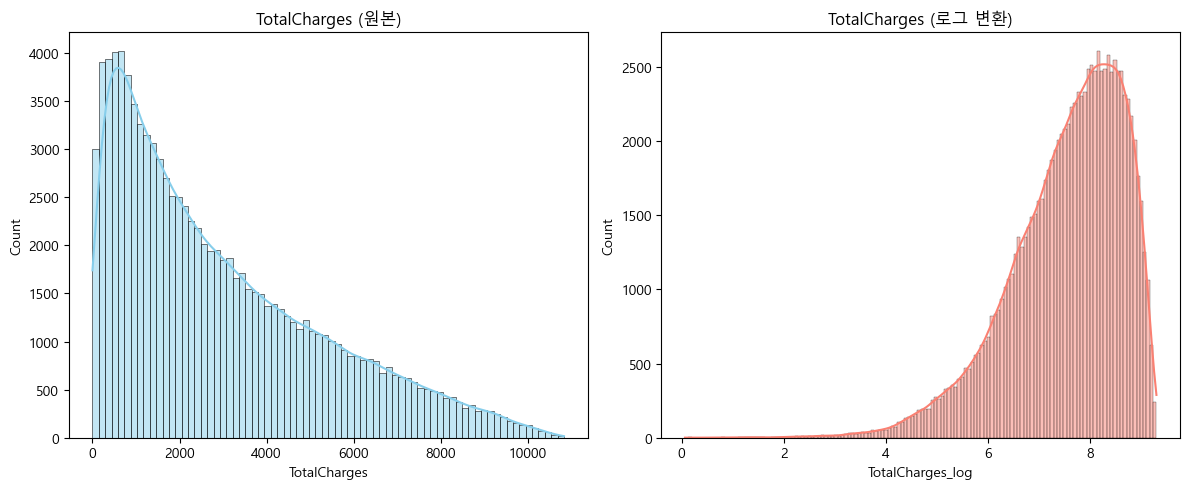

In [ ]:
import numpy as np

# 0 이하 값 제거
df_clean = df[df['TotalCharges'] > 0].copy()
print(f"제거 전 : {len(df):,}개")
print(f"제거 후 : {len(df_clean):,}개")
print(f"제거 수 : {len(df) - len(df_clean):,}개")

# 로그 변환
df_clean['TotalCharges_log'] = np.log1p(df_clean['TotalCharges'])

# 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 원본 분포
sns.histplot(df_clean['TotalCharges'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('TotalCharges (원본)')

# 로그 변환 분포
sns.histplot(df_clean['TotalCharges_log'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('TotalCharges (로그 변환)')

plt.tight_layout()
plt.show()

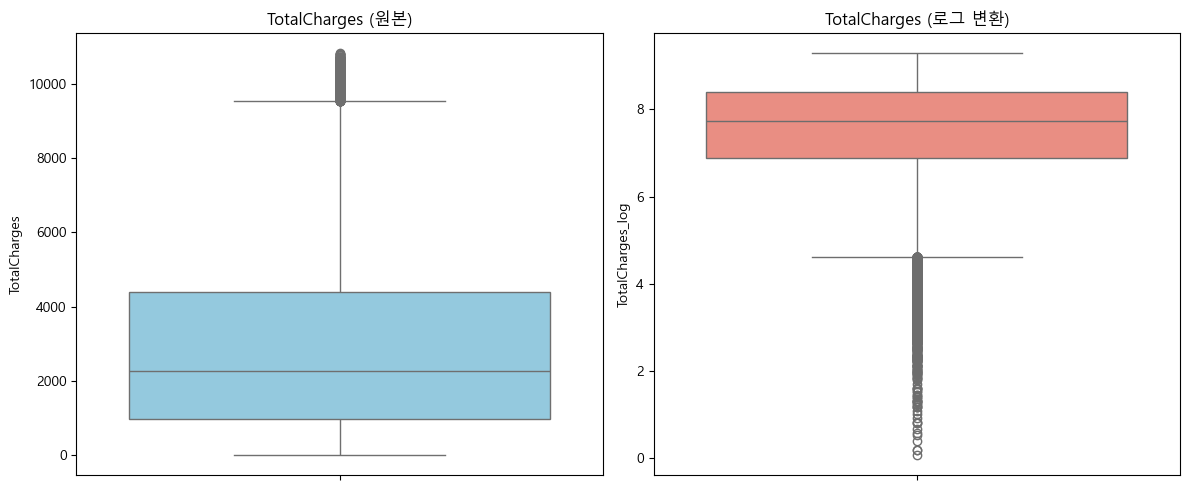

In [11]:
import numpy as np

# 0 이하 값 제거
df_clean = df[df['TotalCharges'] > 0].copy()

# 로그 변환
df_clean['TotalCharges_log'] = np.log1p(df_clean['TotalCharges'])

# 박스플롯
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 원본 분포
sns.boxplot(y=df_clean['TotalCharges'], ax=axes[0], color='skyblue')
axes[0].set_title('TotalCharges (원본)')

# 로그 변환 분포
sns.boxplot(y=df_clean['TotalCharges_log'], ax=axes[1], color='salmon')
axes[1].set_title('TotalCharges (로그 변환)')

plt.tight_layout()
plt.show()


In [15]:
from scipy import stats
import os

# 0 이하 값 제거
df_clean = df[df['TotalCharges'] > 0].copy()
print(f"제거 전 : {len(df):,}개")
print(f"제거 후 : {len(df_clean):,}개")
print(f"제거 수 : {len(df) - len(df_clean):,}개")

# Box-Cox 변환
df_clean['TotalCharges_boxcox'], lambda_ = stats.boxcox(df_clean['TotalCharges'])
print(f"\n최적 lambda : {lambda_:.4f}")

# 저장 경로 설정
output_dir = 'eda_plots'
os.makedirs(output_dir, exist_ok=True)

# 히스토그램 전후 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_clean['TotalCharges'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('TotalCharges (원본)')

sns.histplot(df_clean['TotalCharges_boxcox'], kde=True, ax=axes[1], color='purple')
axes[1].set_title(f'TotalCharges (Box-Cox, λ={lambda_:.4f})')

plt.suptitle('히스토그램 비교', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '07_totalcharges_histogram_boxcox.png'), dpi=150, bbox_inches='tight')
plt.close()
print(f"-> 저장 완료: {output_dir}/07_totalcharges_histogram_boxcox.png")

# 박스플롯 전후 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_clean['TotalCharges'], ax=axes[0], color='skyblue')
axes[0].set_title('TotalCharges (원본)')

sns.boxplot(y=df_clean['TotalCharges_boxcox'], ax=axes[1], color='purple')
axes[1].set_title(f'TotalCharges (Box-Cox, λ={lambda_:.4f})')

plt.suptitle('박스플롯 비교', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '08_totalcharges_boxplot_boxcox.png'), dpi=150, bbox_inches='tight')
plt.close()
print(f"-> 저장 완료: {output_dir}/08_totalcharges_boxplot_boxcox.png")

plt.show()

제거 전 : 100,000개
제거 후 : 99,735개
제거 수 : 265개

최적 lambda : 0.3368
-> 저장 완료: eda_plots/07_totalcharges_histogram_boxcox.png
-> 저장 완료: eda_plots/08_totalcharges_boxplot_boxcox.png


제거 전 : 100,000개
제거 후 : 99,735개
제거 수 : 265개

최적 lambda : 0.3368


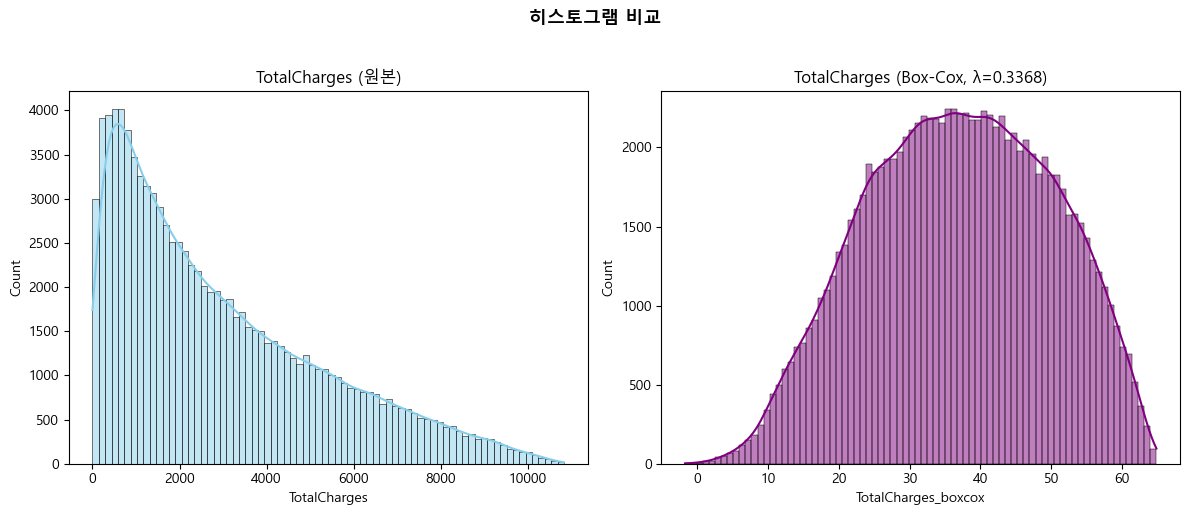

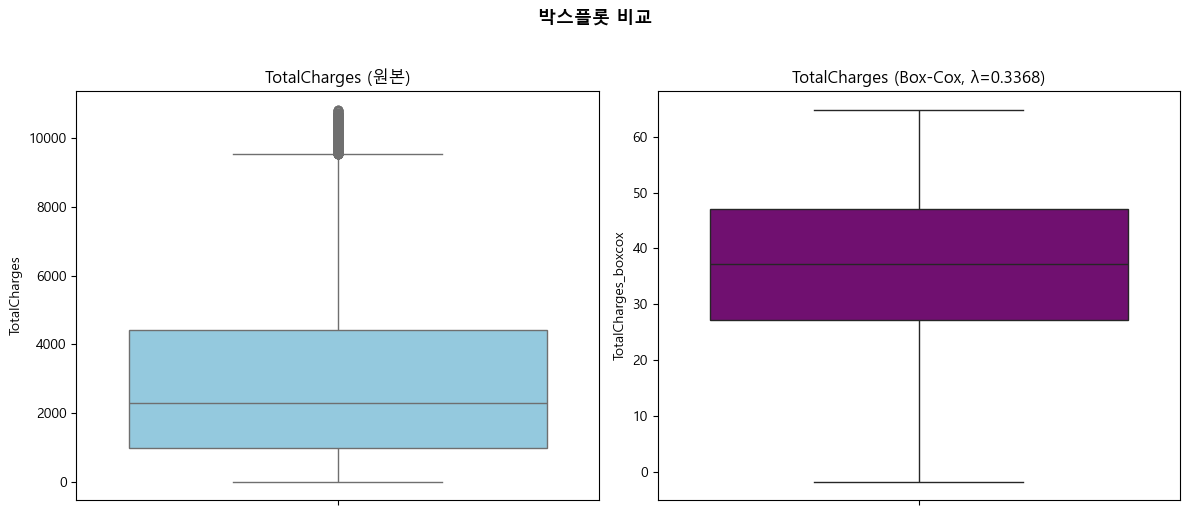

In [14]:
from scipy import stats

# 0 이하 값 제거
df_clean = df[df['TotalCharges'] > 0].copy()
print(f"제거 전 : {len(df):,}개")
print(f"제거 후 : {len(df_clean):,}개")
print(f"제거 수 : {len(df) - len(df_clean):,}개")

# Box-Cox 변환
df_clean['TotalCharges_boxcox'], lambda_ = stats.boxcox(df_clean['TotalCharges'])
print(f"\n최적 lambda : {lambda_:.4f}")

# 히스토그램 전후 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_clean['TotalCharges'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('TotalCharges (원본)')

sns.histplot(df_clean['TotalCharges_boxcox'], kde=True, ax=axes[1], color='purple')
axes[1].set_title(f'TotalCharges (Box-Cox, λ={lambda_:.4f})')

plt.suptitle('히스토그램 비교', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 박스플롯 전후 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_clean['TotalCharges'], ax=axes[0], color='skyblue')
axes[0].set_title('TotalCharges (원본)')

sns.boxplot(y=df_clean['TotalCharges_boxcox'], ax=axes[1], color='purple')
axes[1].set_title(f'TotalCharges (Box-Cox, λ={lambda_:.4f})')

plt.suptitle('박스플롯 비교', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


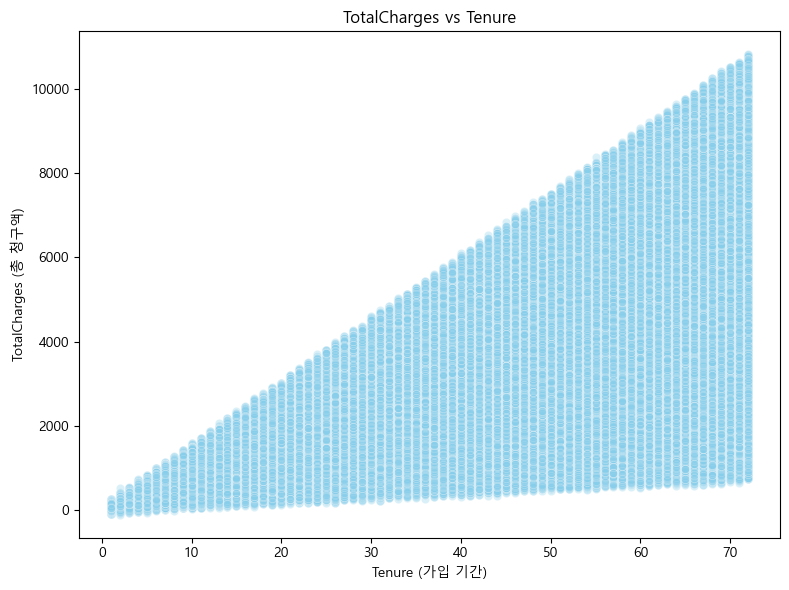

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Tenure', y='TotalCharges', alpha=0.3, color='skyblue')
plt.title('TotalCharges vs Tenure')
plt.xlabel('Tenure (가입 기간)')
plt.ylabel('TotalCharges (총 청구액)')
plt.tight_layout()
plt.show()

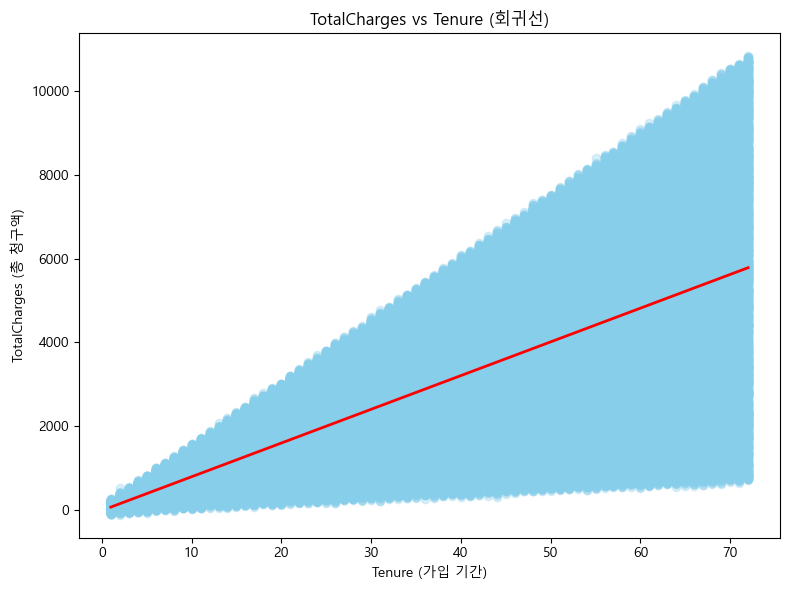

In [ ]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='Tenure', y='TotalCharges', 
            scatter_kws={'alpha': 0.3, 'color': 'skyblue'},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('TotalCharges vs Tenure (회귀선)')
plt.xlabel('Tenure (가입 기간)')
plt.ylabel('TotalCharges (총 청구액)')
plt.tight_layout()
plt.show()